# Анализ закупок группы Сбер за 2024–2025 годы

В ноутбуке собран воспроизводимый аналитический отчёт по открытому контуру ЭТП.

- Юрлиц в периметре: `24`
- Юрлиц с наблюдаемыми закупками: `13`
- Лотов в итоговом слое после дедупликации: `1556`
- Удалено дублей: `65`
- Покрытие ценой: `25%`
- Сумма раскрытых цен: `2 498 248 140.68` RUB
- Строк с unit price: `2310`
- Извлечено документов: `250`
- Строк участников/продавцов: `616`
- Unit-price аномалий: `7`

## 1. Контур источников

Логика решения разделяет `официальный контур идентификации` и `рабочие контуры наблюдения`:

- `ЕИС` используется для резолвинга юридических лиц и контрольной проверки открытого покрытия по 223-ФЗ.
- `Росэлторг` и `Сбербанк-АСТ` используются как рабочие источники публичных карточек процедур.
- Для `Сбербанк-АСТ` дополнительно применяется фильтр по предметной области: из единого реестра исключены процедуры реализации имущества и банкротные продажи, чтобы в аналитический слой попадали только procurement-релевантные записи.
- Остальные ЭТП повторно исследованы и отражены в `source_assessment.csv` как exact-probe / research sources; RTS дополнительно проверен через Playwright и браузерный network trace.

Это важно, потому что задача не только про сбор данных, но и про честную оценку покрытия.

In [1]:
from pathlib import Path
from IPython.display import display as _ipython_display
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
CURATED = ROOT / 'data' / 'curated'

ENTITY_ID_COLUMNS = ['inn', 'resolved_inn', 'eis_resolved_inn', 'eis_resolved_kpp', 'eis_resolved_ogrn']
SOURCE_LINK_ID_COLUMNS = ['external_customer_key', 'external_inn', 'external_kpp']
ID_COLUMN_HINTS = ('inn', 'kpp', 'ogrn', 'fz94', 'fz223', 'procedure_number', 'external_customer_key', 'customer_key', 'tax_id', 'participant_external_id', 'matched_external_id', 'matched_external_inn')

pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
pd.set_option('display.max_colwidth', 120)

def is_identifier_column(column):
    lower = str(column).lower()
    return any(hint in lower for hint in ID_COLUMN_HINTS)

def format_identifier(value):
    if value is None or pd.isna(value):
        return ''
    text = str(value).strip()
    if text.lower() in {'', 'nan', 'none', '<na>'}:
        return ''
    if text.endswith('.0') and text[:-2].isdigit():
        return text[:-2]
    if 'e' in text.lower():
        try:
            number = float(text)
        except ValueError:
            return text
        if number.is_integer():
            return str(int(number))
    return text

def id_columns_for(columns, explicit=()):
    explicit = set(explicit)
    return [column for column in columns if column in explicit or is_identifier_column(column)]

def read_csv_with_ids(path, id_columns=()):
    header = pd.read_csv(path, nrows=0)
    resolved_id_columns = id_columns_for(header.columns.tolist(), id_columns)
    df = pd.read_csv(path, dtype={column: 'string' for column in resolved_id_columns})
    for column in resolved_id_columns:
        if column in df.columns:
            df[column] = df[column].map(format_identifier).astype('string')
    return df

def clean_display_object(obj):
    if isinstance(obj, pd.DataFrame):
        frame = obj.copy()
        for column in frame.columns:
            if is_identifier_column(column):
                frame[column] = frame[column].map(format_identifier).astype('string')
            elif pd.api.types.is_object_dtype(frame[column]) or pd.api.types.is_string_dtype(frame[column]):
                frame[column] = frame[column].fillna('')
        return frame
    if isinstance(obj, pd.Series) and is_identifier_column(obj.name or ''):
        return obj.map(format_identifier).astype('string')
    return obj

def display(*objects, **kwargs):
    return _ipython_display(*(clean_display_object(obj) for obj in objects), **kwargs)

entities = read_csv_with_ids(CURATED / 'entity_coverage.csv', ENTITY_ID_COLUMNS)
source_assessment = read_csv_with_ids(CURATED / 'source_assessment.csv')
entity_links = read_csv_with_ids(CURATED / 'entity_source_links.csv', SOURCE_LINK_ID_COLUMNS)
lots = read_csv_with_ids(CURATED / 'procurement_lots.csv')
yearly = read_csv_with_ids(CURATED / 'mart_yearly_summary.csv')
monthly = read_csv_with_ids(CURATED / 'mart_monthly_activity.csv')
category_mix = read_csv_with_ids(CURATED / 'mart_category_mix.csv')
category_yoy = read_csv_with_ids(CURATED / 'mart_category_yoy.csv')
anomalies = read_csv_with_ids(CURATED / 'mart_anomalies.csv')
duplicate_stats = read_csv_with_ids(CURATED / 'duplicate_stats.csv')
macro = read_csv_with_ids(CURATED / 'mart_monthly_macro_join.csv')
macro_diagnostics = read_csv_with_ids(CURATED / 'mart_macro_diagnostics.csv')
items = read_csv_with_ids(CURATED / 'procurement_items.csv')
document_texts = read_csv_with_ids(CURATED / 'document_texts.csv')
participants = read_csv_with_ids(CURATED / 'procurement_participants.csv')
unit_price_benchmarks = read_csv_with_ids(CURATED / 'mart_unit_price_benchmarks.csv')

source_assessment[['source_system', 'operational_status', 'inclusion_status', 'coverage_note']]

,source_system,operational_status,inclusion_status,coverage_note
0,eis,operational,used_in_pipeline,Used as authoritative customer registry and count-control layer.
1,lot_online,operational,used_in_pipeline_probe_only,"Operational exact-probe adapter implemented; exact INN filters return zero Sber-scope hits, while broad title search..."
2,roseltorg,operational,used_in_pipeline,Used for directly observed lot cards and enrichment.
3,rts_tender,operational,researched_not_used_exact_probe_zero_new,"Strict RTS-only exact probes for 2024-2025 returned zero rows. All-ETP mode found three exact Sber procedures, but a..."
4,sberb2b_public_card,operational,used_as_enrichment,Used to enrich Sberbank-AST rows whose detail_url points to sberb2b.ru; Browser and JS-bundle inspection confirmed t...
5,sberbank_ast,operational,used_in_pipeline,"Used for large 2024-2025 procurement samples on SberB2B / AST public registry; asset-sale, bankruptcy, and VIP sale/..."
6,zakazrf,operational,used_in_pipeline_probe_only,"Operational exact-probe adapter implemented; Sber-scope customer matches currently return zero public notifications,..."
7,etpgpb,research_only,researched_not_used_exact_probe_zero,"Exact customer API confirmed only SberObrazovanie, whose procedures are from 2022; no exact Sber customer lots for 2..."
8,tektorg,research_only,researched_not_used_exact_probe_zero,Exact Sber-scope INN probes returned SOAP faults such as 'Customers not found by INN.' or 'Organizers type not found...


## 2. Связка сущностей между источниками

Ниже показано, как юрлица группы Сбер были связаны с внешними идентификаторами источников.

Observation: для части компаний исходный ИНН в первоначальном scope пришлось скорректировать по ЕИС/AST-резолвингу.

Interpretation: без отдельного шага entity resolution мы получили бы ложные пропуски и слабое покрытие по закупкам.

Significance: это ключевой инженерный шаг для воспроизводимости и качества выгрузки.

Limitation: открытые справочники ЭТП показывают не все внутренние дочерние/региональные сущности одинаково полно.

In [2]:
# Always reload this section data so stale kernel state cannot show float-formatted INNs.
from pathlib import Path
from IPython.display import display as _ipython_display
import pandas as pd

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
CURATED = ROOT / 'data' / 'curated'
ENTITY_ID_COLUMNS = ['inn', 'resolved_inn', 'eis_resolved_inn', 'eis_resolved_kpp', 'eis_resolved_ogrn']
SOURCE_LINK_ID_COLUMNS = ['external_customer_key', 'external_inn', 'external_kpp']
ID_COLUMN_HINTS = ('inn', 'kpp', 'ogrn', 'fz94', 'fz223', 'procedure_number', 'external_customer_key', 'customer_key', 'tax_id', 'participant_external_id', 'matched_external_id', 'matched_external_inn')

def is_identifier_column(column):
    lower = str(column).lower()
    return any(hint in lower for hint in ID_COLUMN_HINTS)

def format_identifier(value):
    if value is None or pd.isna(value):
        return ''
    text = str(value).strip()
    if text.lower() in {'', 'nan', 'none', '<na>'}:
        return ''
    if text.endswith('.0') and text[:-2].isdigit():
        return text[:-2]
    if 'e' in text.lower():
        try:
            number = float(text)
        except ValueError:
            return text
        if number.is_integer():
            return str(int(number))
    return text

def id_columns_for(columns, explicit=()):
    explicit = set(explicit)
    return [column for column in columns if column in explicit or is_identifier_column(column)]

def read_csv_with_ids(path, id_columns=()):
    header = pd.read_csv(path, nrows=0)
    resolved_id_columns = id_columns_for(header.columns.tolist(), id_columns)
    df = pd.read_csv(path, dtype={column: 'string' for column in resolved_id_columns})
    for column in resolved_id_columns:
        if column in df.columns:
            df[column] = df[column].map(format_identifier).astype('string')
    return df

def clean_display_object(obj):
    if isinstance(obj, pd.DataFrame):
        frame = obj.copy()
        for column in frame.columns:
            if is_identifier_column(column):
                frame[column] = frame[column].map(format_identifier).astype('string')
            elif pd.api.types.is_object_dtype(frame[column]) or pd.api.types.is_string_dtype(frame[column]):
                frame[column] = frame[column].fillna('')
        return frame
    if isinstance(obj, pd.Series) and is_identifier_column(obj.name or ''):
        return obj.map(format_identifier).astype('string')
    return obj

def display(*objects, **kwargs):
    return _ipython_display(*(clean_display_object(obj) for obj in objects), **kwargs)

entities = read_csv_with_ids(CURATED / 'entity_coverage.csv', ENTITY_ID_COLUMNS)
entity_links = read_csv_with_ids(CURATED / 'entity_source_links.csv', SOURCE_LINK_ID_COLUMNS)

display(entities[['entity_name', 'inn', 'resolved_inn', 'eis_223_open_count', 'roseltorg_lot_count', 'sberbank_ast_lot_count']])
display(entity_links[['entity_name', 'source_system', 'external_customer_key', 'records_total']].head(40))

,entity_name,inn,resolved_inn,eis_223_open_count,roseltorg_lot_count,sberbank_ast_lot_count
0,ООО Сбербанк-Телеком,7736264044,7736264044,0,15,253
1,АО НПФ Сбербанка,,7725352740,0,0,0
2,АО Сбербанк Лизинг,7707009586,7707009586,0,0,197
3,АО Сбербанк Управление Активами,,,0,0,0
4,АО Сбербанк-АСТ,7707308480,7707308480,0,0,25
5,ООО Домклик,,7736249247,0,0,37
6,ООО ЕАПТЕКА,,,0,601,48
7,ООО Купер,,,0,0,0
8,ООО СК Сбербанк Страхование,,7744002123,0,0,21
9,ООО СК Сбербанк Страхование Жизни,7744002123,7744002123,0,0,21


,entity_name,source_system,external_customer_key,records_total
0,АО НПФ Сбербанка,eis,7725352740_772501001_1147799009160,0
1,АО НПФ Сбербанка,sberbank_ast,7725352740_772501001,5
2,АО Сбербанк Лизинг,eis,7707009586_503201001_1027739000728,0
3,АО Сбербанк Лизинг,sberbank_ast,7707009586_503201001,701
4,АО Сбербанк-АСТ,eis,07730000042,0
5,АО Сбербанк-АСТ,sberbank_ast,7707308480_770701001,0
6,АО Сбербанк-АСТ,sberbank_ast,7707308480_770401001,239
7,АО Сбербанк-АСТ,zakazrf,202380,0
8,ООО Домклик,eis,12007000072,0
9,ООО Домклик,sberbank_ast,7736249247_773001001,37


## 3. Сравнение 2024 vs 2025

Ниже — базовое сравнение числа лотов и раскрытого стоимостного объёма по годам.

,publication_year,lots_count,total_price_rub,median_price_rub,unique_regions,unique_categories,unique_sources
0,2024,256,"1,633,417,142.23","2,552,500.00",1,8,1
1,2025,684,"862,705,473.45","271,040.00",1,8,1


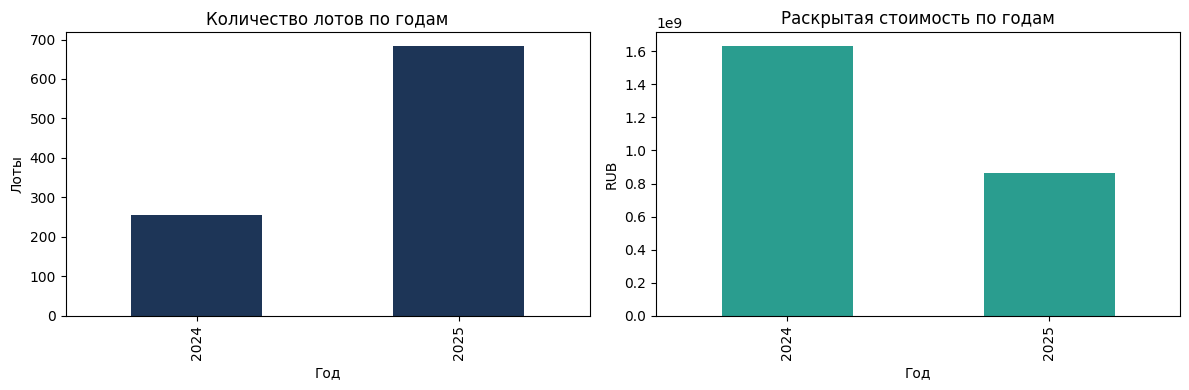

In [3]:
display(yearly)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
yearly.plot(x='publication_year', y='lots_count', kind='bar', ax=axes[0], legend=False, color='#1D3557')
axes[0].set_title('Количество лотов по годам')
axes[0].set_xlabel('Год')
axes[0].set_ylabel('Лоты')
yearly.plot(x='publication_year', y='total_price_rub', kind='bar', ax=axes[1], legend=False, color='#2A9D8F')
axes[1].set_title('Раскрытая стоимость по годам')
axes[1].set_xlabel('Год')
axes[1].set_ylabel('RUB')
plt.tight_layout()
plt.show()

Observation: в 2025 году открытый procurement-контур заметно активнее и по количеству лотов, и по раскрытой стоимости.

Interpretation: часть эффекта связана с более широким публичным покрытием AST в 2025 году и активизацией коммерческих закупок в цифровом/операционном контуре.

Significance: даже без полного внутреннего доступа можно уверенно зафиксировать межгодовой сдвиг активности.

Limitation: это не полная группа Сбер и не полный closed-loop procurement, а только наблюдаемый публичный слой.

## 4. Ключевое направление: Telecom & Devices

В качестве ключевого направления выбрано `Telecom & Devices`, потому что оно одновременно:

- хорошо наблюдается в открытых данных,
- содержит заметный стоимостной объём,
- даёт предметные закупочные сюжеты, а не только общие процедуры.

,publication_year,focus_category,lots_count,total_price_rub,prev_year_lots_count,prev_year_total_price_rub,lots_count_delta,lots_count_growth_ratio,total_price_delta_rub,total_price_growth_ratio
14,2024,Telecom & Devices,47,"327,739,599.00",NaN,NaN,NaN,NaN,NaN,NaN
15,2025,Telecom & Devices,122,"668,264,970.23",47.00,"327,739,599.00",75.00,2.60,"340,525,371.23",2.04


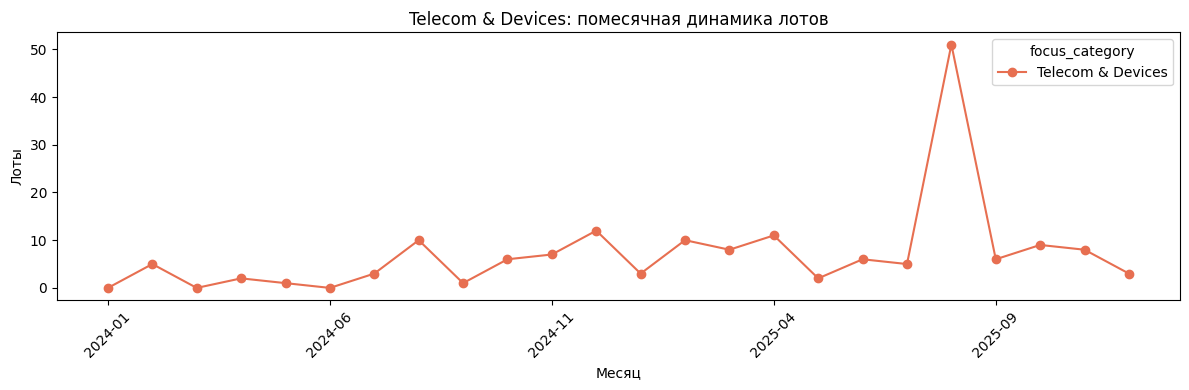

In [4]:
telecom_yoy = category_yoy[category_yoy['focus_category'] == 'Telecom & Devices'].copy()
display(telecom_yoy)
monthly_pivot = monthly.pivot_table(index='publication_month', columns='focus_category', values='lots_count', fill_value=0)
monthly_pivot[['Telecom & Devices']].plot(figsize=(12, 4), marker='o', color='#E76F51')
plt.title('Telecom & Devices: помесячная динамика лотов')
plt.xlabel('Месяц')
plt.ylabel('Лоты')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Observation: направление `Telecom & Devices` выросло по количеству лотов примерно в `2.60x` между 2024 и 2025 годами.

Interpretation: это согласуется с публично наблюдаемыми закупками оборудования, лицензий, сетевой инфраструктуры и профильных ИТ-услуг.

Significance: направление можно использовать как приоритетное окно для детального мониторинга технологических потребностей группы.

Limitation: часть общих ИТ/операционных закупок остаётся в категории `Other`, потому что названия процедур не всегда достаточно структурированы.

## 5. Топ дорогих лотов

Здесь рассматриваются все закупочные лоты после фильтрации out-of-scope процедур: товары, работы и услуги. В 44-ФЗ и 223-ФЗ оказание услуг также относится к закупкам, поэтому строки вида `Оказание услуг...` корректно попадают в общий рейтинг. Этот блок нужен для отбора крупных процедур и ручной проверки, а не для вывода о завышенной цене за единицу. Для проверки завышения цен ниже используется отдельный контур unit-price benchmarks по сопоставимым позициям с единицами измерения.

,entity_name,platform_section,subject,focus_category,price_rub,published_at,detail_url
709,ПАО Сбербанк России,Госзакупки по 44-ФЗ,Оказание аудиторских услуг ПАО Сбербанк,Consulting,"1,066,759,667.00",2024-12-04 14:28:00,https://www.sberbank-ast.ru/OK/purchaseview.aspx?id=10184329
324,ООО Сбербанк-Телеком,Торги коммерческих заказчиков,"Поставка и внедрение Программного Комплекса, включающего функциональные модули: PCEF, DPI, TDF для нужд ООО Сбербанк...",Telecom & Devices,"186,025,058.33",2025-09-16 15:47:00,https://utp.sberbank-ast.ru/VIP/NBT/PurchaseView/45/0/0/3413508
806,ООО Сбербанк-Телеком,Торги коммерческих заказчиков,Оказание комплекса услуг по проведению приемки-передачи предметов лизинга для нужд ООО «Сбербанк-Телеком»,Telecom & Devices,"160,489,600.00",2024-10-01 22:18:00,https://utp.sberbank-ast.ru/VIP/NBT/PurchaseView/45/0/0/2348639
395,ООО Сбербанк-Телеком,Торги коммерческих заказчиков,Поставка аппаратного обеспечения для ООО Сбербанк-Телеком,Telecom & Devices,"155,097,500.00",2025-08-21 23:13:00,https://utp.sberbank-ast.ru/VIP/NBT/PurchaseView/48/0/0/3350017
762,ООО Сбербанк-Телеком,Торги коммерческих заказчиков,Оказание комплекса услуг по проведению приемки-передачи предметов лизинга для нужд ООО «Сбербанк-Телеком»,Telecom & Devices,"101,000,000.00",2024-11-02 12:16:00,https://utp.sberbank-ast.ru/VIP/NBT/PurchaseView/45/0/0/2444890
265,ООО Сбербанк-Телеком,Торги коммерческих заказчиков,Поставка и внедрение части компонентов нового биллингового решения BILRND (2-я часть компонентов) для ООО «СБЕРБАНК-...,Telecom & Devices,"99,999,999.00",2025-10-14 18:29:00,https://utp.sberbank-ast.ru/VIP/NBT/PurchaseView/45/0/0/3485637
280,ООО Сбербанк-Телеком,Торги коммерческих заказчиков,Поставка сетевого оборудования (коммутаторы ЦОД) для ООО Сбербанк-Телеком,Telecom & Devices,"56,526,412.96",2025-10-10 16:21:00,https://utp.sberbank-ast.ru/VIP/NBT/PurchaseView/48/0/0/3477662
844,ООО Сбербанк-Телеком,Торги коммерческих заказчиков,ОКАЗАНИЕ УСЛУГ ПРОВЕДЕНИЯ ИМИДЖЕВОЙ ФОТОСЕССИИ ДЛЯ НУЖД ООО «СБЕРБАНК-ТЕЛЕКОМ»,Telecom & Devices,"49,999,999.00",2024-08-19 13:34:00,https://utp.sberbank-ast.ru/VIP/NBT/PurchaseView/45/0/0/2230349
899,ООО СберАвто,"Торги коммерческих заказчиков (ранее ТС ""Закупки и продажи"")",Оказание услуг по осмотру автомобилей,Other,"27,154,200.00",2024-05-20 10:07:00,https://utp.sberbank-ast.ru/VIP/NBT/PurchaseView/29/0/0/1946576
833,ООО Сбербанк-Телеком,Торги коммерческих заказчиков,На услуги по ведению и продвижению официальных аккаунтов СберМобайл в социальных сетях,Other,"20,000,000.00",2024-08-29 20:53:00,https://utp.sberbank-ast.ru/VIP/NBT/PurchaseView/45/0/0/2259044


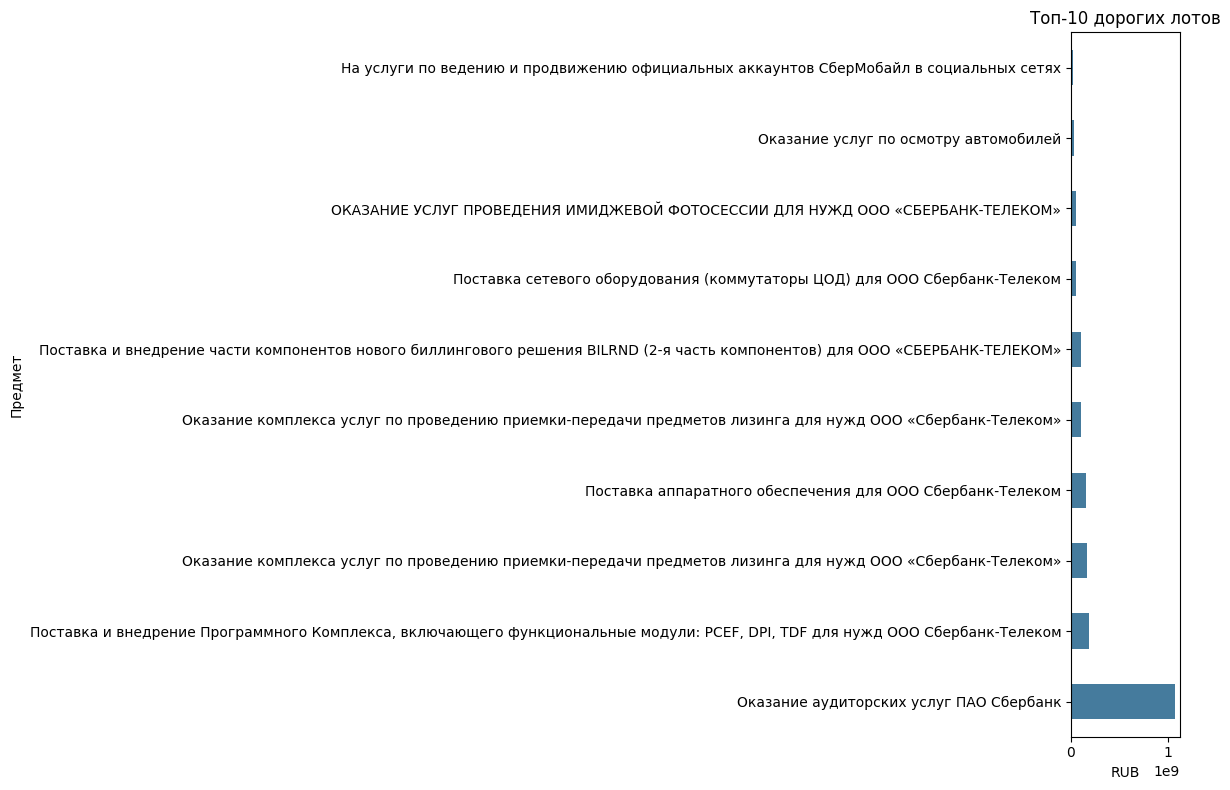

In [5]:
top_lots = (
    lots[['entity_name', 'platform_section', 'subject', 'focus_category', 'price_rub', 'published_at', 'detail_url']]
    .sort_values('price_rub', ascending=False)
    .head(20)
)
display(top_lots)
top_lots.head(10).plot(kind='barh', x='subject', y='price_rub', figsize=(12, 8), color='#457B9D', legend=False)
plt.title('Топ-10 дорогих лотов')
plt.xlabel('RUB')
plt.ylabel('Предмет')
plt.tight_layout()
plt.show()

Observation: верхние строки формируются в основном за счёт крупных телеком- и инфраструктурных закупок, особенно в контуре `ООО Сбербанк-Телеком`.

Interpretation: открытый публичный след особенно хорошо отражает крупные конкурентные процедуры с существенной закупочной стоимостью.

Significance: этот блок уже подходит для short-list ручной проверки, контроля категорий и последующей supplier-аналитики.

Limitation: по части процедур цена всё ещё не раскрывается, поэтому top-value лист не эквивалентен полной картине расходов.

## 6. Корреляция с макрофакторами

Проверяем исследовательскую гипотезу: меняется ли открытая закупочная активность вместе с динамикой `USD/RUB` и ключевой ставки.

,publication_month,lots_count,total_price_rub,avg_price_rub,avg_usd_rub,avg_key_rate,inflation_yoy_pct,inflation_target_pct,corr_total_vs_usd,corr_total_vs_key_rate,corr_total_vs_inflation,corr_lots_vs_usd,corr_lots_vs_key_rate,corr_lots_vs_inflation
0,2024-01,2,NaN,NaN,88.68,16.00,7.44,4.00,0.35,0.24,0.08,-0.50,0.04,-0.36
1,2024-02,18,"10,299,581.34","3,433,193.78",91.52,16.00,7.69,4.00,0.35,0.24,0.08,-0.50,0.04,-0.36
2,2024-03,8,"5,683,098.33","2,841,549.17",91.73,16.00,7.72,4.00,0.35,0.24,0.08,-0.50,0.04,-0.36
3,2024-04,9,"24,196,666.67","12,098,333.34",92.96,16.00,7.84,4.00,0.35,0.24,0.08,-0.50,0.04,-0.36
4,2024-05,7,"27,354,200.00","9,118,066.67",90.61,16.00,8.30,4.00,0.35,0.24,0.08,-0.50,0.04,-0.36
5,2024-06,9,"1,611,378.44","805,689.22",87.76,16.00,8.59,4.00,0.35,0.24,0.08,-0.50,0.04,-0.36
6,2024-07,14,"11,474,196.00","5,737,098.00",87.49,16.26,9.13,4.00,0.35,0.24,0.08,-0.50,0.04,-0.36
7,2024-08,41,"117,519,107.00","10,683,555.18",89.16,18.00,9.05,4.00,0.35,0.24,0.08,-0.50,0.04,-0.36
8,2024-09,24,"40,279,519.24","4,027,951.92",91.23,18.52,8.63,4.00,0.35,0.24,0.08,-0.50,0.04,-0.36
9,2024-10,44,"181,045,547.68","18,104,554.77",96.16,19.35,8.54,4.00,0.35,0.24,0.08,-0.50,0.04,-0.36


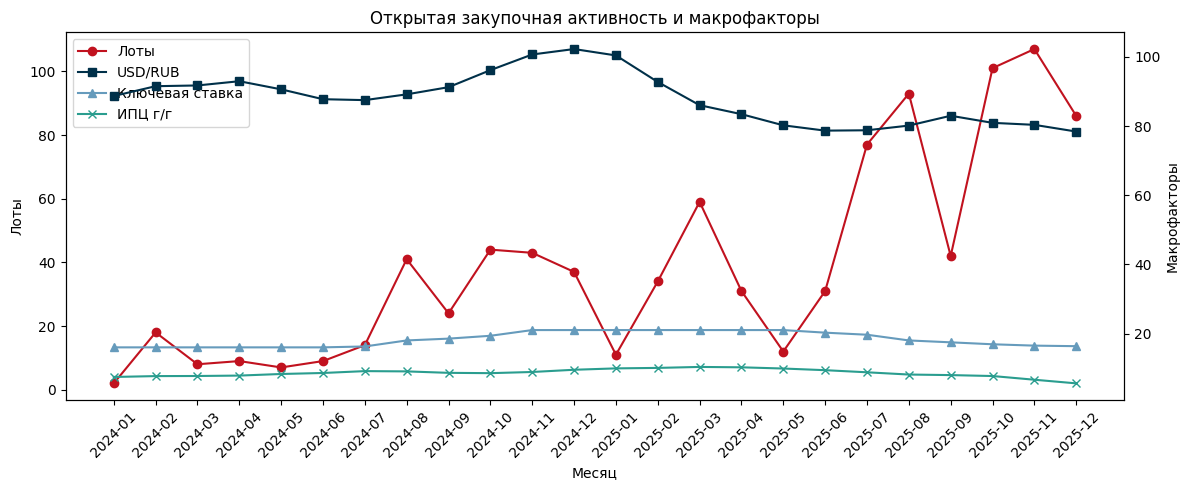

,metric,factor,observations,pearson_r,approx_p_value_fisher_z,statistical_note
0,total_price_rub,avg_usd_rub,23,0.35,0.10,directional_only_small_sample
1,total_price_rub,avg_key_rate,23,0.24,0.28,directional_only_small_sample
2,total_price_rub,inflation_yoy_pct,23,0.08,0.72,directional_only_small_sample
3,lots_count,avg_usd_rub,24,-0.50,0.01,interpret_with_procurement_coverage_limits
4,lots_count,avg_key_rate,24,0.04,0.86,interpret_with_procurement_coverage_limits
5,lots_count,inflation_yoy_pct,24,-0.36,0.09,interpret_with_procurement_coverage_limits


In [6]:
display(macro)
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(macro['publication_month'], macro['lots_count'], color='#C1121F', marker='o', label='Лоты')
ax1.set_ylabel('Лоты')
ax1.set_xlabel('Месяц')
ax1.tick_params(axis='x', rotation=45)
ax2 = ax1.twinx()
ax2.plot(macro['publication_month'], macro['avg_usd_rub'], color='#003049', marker='s', label='USD/RUB')
ax2.plot(macro['publication_month'], macro['avg_key_rate'], color='#669BBC', marker='^', label='Ключевая ставка')
if 'inflation_yoy_pct' in macro:
    ax2.plot(macro['publication_month'], macro['inflation_yoy_pct'], color='#2A9D8F', marker='x', label='ИПЦ г/г')
ax2.set_ylabel('Макрофакторы')
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
plt.title('Открытая закупочная активность и макрофакторы')
plt.tight_layout()
plt.show()
display(macro_diagnostics)

Observation: текущий open-data sample даёт отрицательную корреляцию `lots_count vs USD` на уровне `-0.503` и отрицательную корреляцию `total_price vs key_rate` на уровне `0.236`.

Interpretation: это больше похоже на исследовательский сигнал, чем на устойчивую причинную связь.

Significance: архитектура уже позволяет регулярно проверять подобные гипотезы и расширять набор внешних факторов.

Limitation: выборка короткая и частично смещена в сторону отдельных источников, поэтому статистическую силу здесь нельзя переоценивать.

## 7. Дедупликация, документы и ПДн

Отдельно фиксируем служебные аспекты качества данных: дубли, документы, извлечение текста и обезличивание.

In [7]:
display(duplicate_stats)
docs = pd.read_csv(CURATED / 'document_links.csv')
display(docs.head(20))
display(document_texts[['procedure_number', 'document_name', 'extraction_method', 'text_chars', 'ocr_required', 'pii_findings_count']].head(30))
document_texts[['text_chars', 'pii_findings_count']].describe()

,source_system,entity_name,duplicate_groups,duplicate_rows_removed
0,sberbank_ast,ООО СК Сбербанк Страхование Жизни,21,63
1,sberbank_ast,ООО Сбербанк-Телеком,1,2


C:\Users\nekra\AppData\Local\Temp\ipykernel_980\1855106535.py:53: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  frame[column] = frame[column].fillna('')


,source_system,procedure_number,lot_number,document_name,document_url,document_storage_name,document_mime_type,document_size_bytes,document_hash,is_available,local_path,extraction_method,text_chars,ocr_required,pii_findings_count
0,sberbank_ast,60010033,1,"ТФД закупка до 500 тр _24.12.2025, 08_57_17.docx",https://sberb2b.ru/uploads/documents/09/cb4/fcb/09cb4fcbc84d1b0020f0c699767cd111.bin,09cb4fcbc84d1b0020f0c699767cd111.bin,application/vnd.openxmlformats-officedocument.wordprocessingml.document,"372,504.00",09cb4fcbc84d1b0020f0c699767cd111,True,"D:\Nikita\Work\purchase_analysis\data\raw\sberb2b\documents\60010033_001_ТФД закупка до 500 тр _24.12.2025, 08_57_17...",docx_xml,"71,831.00",False,2.00
1,sberbank_ast,60010033,1,Техническое задание.docx,https://sberb2b.ru/uploads/documents/41/88a/1b8/4188a1b8b3d675a26b9c34c90e6cd910.bin,4188a1b8b3d675a26b9c34c90e6cd910.bin,application/vnd.openxmlformats-officedocument.wordprocessingml.document,"26,045.00",4188a1b8b3d675a26b9c34c90e6cd910,True,D:\Nikita\Work\purchase_analysis\data\raw\sberb2b\documents\60010033_002_Техническое задание.docx,docx_xml,"1,655.00",False,0.00
2,sberbank_ast,16457469,1,"ТФД закупка до 500 тр _22.12.2025, 10_23_17.docx",https://sberb2b.ru/uploads/documents/68/e7e/0ac/68e7e0ac05a57ad9601ea52e3b58b03e.bin,68e7e0ac05a57ad9601ea52e3b58b03e.bin,application/vnd.openxmlformats-officedocument.wordprocessingml.document,"372,529.00",68e7e0ac05a57ad9601ea52e3b58b03e,True,"D:\Nikita\Work\purchase_analysis\data\raw\sberb2b\documents\16457469_001_ТФД закупка до 500 тр _22.12.2025, 10_23_17...",docx_xml,"71,831.00",False,2.00
3,sberbank_ast,16457469,1,Техническое задание.docx,https://sberb2b.ru/uploads/documents/aa/b40/c22/aab40c2264b4f47e35504786fbf9dfcf.bin,aab40c2264b4f47e35504786fbf9dfcf.bin,application/vnd.openxmlformats-officedocument.wordprocessingml.document,"25,824.00",aab40c2264b4f47e35504786fbf9dfcf,True,D:\Nikita\Work\purchase_analysis\data\raw\sberb2b\documents\16457469_002_Техническое задание.docx,docx_xml,"1,394.00",False,0.00
4,sberbank_ast,63260656,1,"ТФД закупка до 500 тр _22.12.2025, 07_08_19.docx",https://sberb2b.ru/uploads/documents/54/71d/07e/5471d07e1e7f6f6e1730ae94fbb3083b.bin,5471d07e1e7f6f6e1730ae94fbb3083b.bin,application/vnd.openxmlformats-officedocument.wordprocessingml.document,"372,503.00",5471d07e1e7f6f6e1730ae94fbb3083b,True,"D:\Nikita\Work\purchase_analysis\data\raw\sberb2b\documents\63260656_001_ТФД закупка до 500 тр _22.12.2025, 07_08_19...",docx_xml,"71,831.00",False,2.00
5,sberbank_ast,63260656,1,Техническое задание.docx,https://sberb2b.ru/uploads/documents/6c/4ac/01d/6c4ac01d39b41823ae4492a4e8d2bffc.bin,6c4ac01d39b41823ae4492a4e8d2bffc.bin,application/vnd.openxmlformats-officedocument.wordprocessingml.document,"25,891.00",6c4ac01d39b41823ae4492a4e8d2bffc,True,D:\Nikita\Work\purchase_analysis\data\raw\sberb2b\documents\63260656_002_Техническое задание.docx,docx_xml,"1,460.00",False,0.00
6,sberbank_ast,31312397,1,Техническое задание.docx,https://sberb2b.ru/uploads/documents/91/506/c57/91506c571de3e415aa0ed2ba412011b1.bin,91506c571de3e415aa0ed2ba412011b1.bin,application/vnd.openxmlformats-officedocument.wordprocessingml.document,"26,265.00",91506c571de3e415aa0ed2ba412011b1,True,D:\Nikita\Work\purchase_analysis\data\raw\sberb2b\documents\31312397_001_Техническое задание.docx,docx_xml,"1,979.00",False,0.00
7,sberbank_ast,31312397,1,"ТФД закупка до 500 тр _17.12.2025, 09_09_17.docx",https://sberb2b.ru/uploads/documents/8f/52f/47c/8f52f47cd12eca9124045a74eac57451.bin,8f52f47cd12eca9124045a74eac57451.bin,application/vnd.openxmlformats-officedocument.wordprocessingml.document,"372,497.00",8f52f47cd12eca9124045a74eac57451,True,"D:\Nikita\Work\purchase_analysis\data\raw\sberb2b\documents\31312397_002_ТФД закупка до 500 тр _17.12.2025, 09_09_17...",docx_xml,"71,831.00",False,2.00
8,sberbank_ast,10957568,1,"ТФД закупка до 500 тр _17.12.2025, 03_34_19.docx",https://sberb2b.ru/uploads/documents/71/d58/c06/71d58c06a986e20314cbcc403cf722e2.bin,71d58c06

,procedure_number,document_name,extraction_method,text_chars,ocr_required,pii_findings_count
0,100680663,"ТФД закупка до 500 тр _24.12.2025, 08_32_15.docx",docx_xml,71882,False,4
1,100680663,Техническое задание.docx,docx_xml,1539,False,0
2,101381336,"ТФД закупка до 500 тр _06.08.2025, 12_25_53.docx",docx_xml,55947,False,0
3,101381336,Техническое задание.docx,docx_xml,3208,False,0
4,101473831,"ТФД закупка до 500 тр _14.11.2025, 10_26_10.docx",docx_xml,67570,False,4
5,101473831,Техническое задание.docx,docx_xml,2263,False,0
6,101519415,Договор № 2511_2025.DOC,unsupported,0,False,0
7,101879042,"ТФД закупка до 500 тр _02.12.2025, 07_25_14.docx",docx_xml,67500,False,4
8,101879042,Техническое задание.docx,docx_xml,1832,False,0
9,101938044,ТЗ блокноты.docx,docx_xml,752,False,0


,text_chars,pii_findings_count
count,250.00,250.00
mean,"17,312.40",0.85
std,"27,109.89",1.37
min,0.00,0.00
25%,"1,607.00",0.00
50%,"2,913.00",0.00
75%,"9,102.00",1.00
max,"72,243.00",4.00


Observation: документы SberB2B скачиваются ограниченным лимитом, текст извлекается из DOCX/PDF, а email/телефоны и похожие идентификаторы маскируются до попадания в витрину.

Interpretation: это превращает вложения из формального списка файлов в источник требований, номенклатуры и признаков цены.

Significance: блок закрывает ожидаемый в ТЗ навык проверки скачанных данных, обезличивания и подготовки данных для LLM/OCR-контура.

Limitation: если PDF почти не содержит текстового слоя, строка помечается `ocr_required=True`; OCR вынесен как следующий контролируемый шаг, чтобы не смешивать уверенный текст с распознаванием сомнительного качества.

## 8. Участники и продавцы

In [8]:
display(participants.head(50))
participants.groupby(['source_system', 'participant_role', 'is_winner'], dropna=False).size().reset_index(name='rows')

,source_system,procedure_number,lot_number,participant_role,participant_name,participant_inn,participant_external_id,offer_price_rub,is_winner,evidence_source
0,roseltorg,B0104251649415,1,seller_from_public_schema,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ЕАПТЕКА""",7704865540,,0.00,False,roseltorg_json_ld_offers_seller
1,roseltorg,B0104251710318,1,seller_from_public_schema,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ЕАПТЕКА""",7704865540,,0.00,False,roseltorg_json_ld_offers_seller
2,roseltorg,B0204251251223,1,seller_from_public_schema,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ЕАПТЕКА""",7704865540,,0.00,False,roseltorg_json_ld_offers_seller
3,roseltorg,B0204251251223,2,seller_from_public_schema,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ЕАПТЕКА""",7704865540,,0.00,False,roseltorg_json_ld_offers_seller
4,roseltorg,B0210251122051,1,seller_from_public_schema,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ЕАПТЕКА""",7704865540,,0.00,False,roseltorg_json_ld_offers_seller
5,roseltorg,B0404251235097,1,seller_from_public_schema,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ЕАПТЕКА""",7704865540,,0.00,False,roseltorg_json_ld_offers_seller
6,roseltorg,B0404251437167,1,seller_from_public_schema,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ЕАПТЕКА""",7704865540,,0.00,False,roseltorg_json_ld_offers_seller
7,roseltorg,B0404251437167,2,seller_from_public_schema,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ЕАПТЕКА""",7704865540,,0.00,False,roseltorg_json_ld_offers_seller
8,roseltorg,B0404251437167,3,seller_from_public_schema,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ЕАПТЕКА""",7704865540,,0.00,False,roseltorg_json_ld_offers_seller
9,roseltorg,B0404251437167,4,seller_from_public_schema,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ЕАПТЕКА""",7704865540,,0.00,False,roseltorg_json_ld_offers_seller


,source_system,participant_role,is_winner,rows
0,roseltorg,seller_from_public_schema,False,616


Observation: Roseltorg detail cards expose `seller` from public JSON-LD, while public SberB2B cards in tested access mode do not expose winner/offer lists.

Interpretation: участники вынесены в отдельную таблицу с evidence_source, чтобы не смешивать продавца из карточки и фактического победителя.

Significance: это честный participant-level слой: он показывает, что извлечено, и явно фиксирует отсутствие победителей в публичном контуре.

Limitation: `winners_total=0` означает не провал парсинга, а отсутствие подтверждённого публичного winner endpoint без авторизации.

## 9. Unit-price benchmarks

In [9]:
unit_flags = unit_price_benchmarks[unit_price_benchmarks['unit_price_anomaly_flag'] == True]
display(unit_flags.head(50))
unit_price_benchmarks['observations'].describe()

,source_system,entity_name,procedure_number,lot_number,line_no,item_name,okpd_code,okpd_name,quantity,unit,unit_price_rub,line_total_rub,benchmark_key,observations,median_unit_price_rub,p75_unit_price_rub,ratio_to_median_unit_price,unit_price_anomaly_flag
0,sberbank_ast,АО Сбербанк Лизинг,29346472,1,1,выбор поставщика на оказание услуг по поставке бытовой техники для нужд Дальневосточного регионального филиала АО «С...,,,1.00,шт,"200,000.00","200,000.00",|шт|выбор поставщика оказание услуг поставке бытовой техники для нужд дальневосточного,4,"75,000.00","125,000.00",2.67,True
1,sberbank_ast,ООО Домклик,116156044,1,2,Бумага офисная Комус Документ Standard А3 80 г/кв.м марка С 146 CIE (500 листов) или эквивалент,,,1.00,упак,724.26,724.26,|упак|бумага офисная комус документ standard марка 146 cie 500 листов,3,362.10,543.18,2.00,True
2,sberbank_ast,ПАО Сбербанк России,109575881,1,2,Стол монтажный (ДиКом или эквивалент),31.09.11.190,"Мебель металлическая хозяйственно-бытового назначения прочая, не включенная в другие группировки",1.00,шт,"140,000.00","140,000.00",31.09.11|шт|стол монтажный диком или эквивалент,2,"70,095.00","105,047.50",2.00,True
3,sberbank_ast,ПАО Сбербанк России,11651097,1,7,Лоток навесной на экран (ДиКом 19.0013-030 или эквивалент),22.22.13.190,"Коробки, ящики, корзины и аналогичные пластмассовые изделия прочие",2.00,шт,"55,600.00","111,200.00",22.22.13|шт|лоток навесной экран диком 0013 030 или эквивалент,2,"28,925.00","42,262.50",1.92,True
4,sberbank_ast,ПАО Сбербанк России,53266154,1,10,Комплект блинов «Barbel” (или аналог) 2 шт в комплекте,32.30.14.115,Инвентарь и оборудование для тяжелой атлетики,1.00,шт,"22,128.07","22,128.07",32.30.14|шт|комплект блинов barbel или аналог комплекте,6,"11,861.51","17,850.34",1.87,True
5,sberbank_ast,ПАО Сбербанк России,11651097,1,6,Крючок навесной на экран (ДиКом 19.0008-100 или эквивалент),26.30.60.190,"Части устройств охранной или пожарной сигнализации и аналогичной аппаратуры прочие, не включенные в другие группировки",10.00,шт,"2,250.00","22,500.00",26.30.60|шт|крючок навесной экран диком 0008 100 или эквивалент,2,"1,220.00","1,735.00",1.84,True
6,sberbank_ast,ООО СберТех,21219629,1,2,Визитные карточки,,,1.00,упак,"14,930.00","14,930.00",|упак|визитные карточки,2,"8,215.00","11,572.50",1.82,True


count   709.00
mean      1.50
std       1.14
min       1.00
25%       1.00
50%       1.00
75%       2.00
max       8.00
Name: observations, dtype: float64

Observation: SberB2B goods API даёт строковые позиции с OKPD2, количеством, единицей измерения и unit price.

Interpretation: это позволяет перейти от анализа дорогих лотов к сравнению типовых товаров: бумага, мебель, спортинвентарь, печать, бытовая техника.

Significance: именно здесь появляется максимальная бизнес-ценность тестового — поиск завышенных цен по сопоставимым позициям, а не только красивый dashboard.

Limitation: benchmark требует достаточного числа наблюдений и нормализации наименований; поэтому флаги являются shortlist для ручной проверки, а не автоматическим обвинением.

## 10. Аномалии

In [10]:
display(anomalies.head(50))
anomalies['anomaly_type'].value_counts()

,entity_name,procedure_number,lot_number,subject,focus_category,price_rub,category_median_price,value_ratio_to_category_median,anomaly_type,anomaly_reason,detail_url
0,ПАО Сбербанк России,1895000000824000001,1,Оказание аудиторских услуг ПАО Сбербанк,Consulting,"1,066,759,667.00","1,200,000.00",888.97,price_outlier,price >= 2x category median,https://www.sberbank-ast.ru/OK/purchaseview.aspx?id=10184329
1,ООО Сбербанк-Телеком,SBR028-2509160031.1,1,"Поставка и внедрение Программного Комплекса, включающего функциональные модули: PCEF, DPI, TDF для нужд ООО Сбербанк...",Telecom & Devices,"186,025,058.33","2,500,000.00",74.41,price_outlier,price >= 2x category median,https://utp.sberbank-ast.ru/VIP/NBT/PurchaseView/45/0/0/3413508
2,ООО Сбербанк-Телеком,SBR028-2410010034.1,1,Оказание комплекса услуг по проведению приемки-передачи предметов лизинга для нужд ООО «Сбербанк-Телеком»,Telecom & Devices,"160,489,600.00","2,500,000.00",64.20,price_outlier,price >= 2x category median,https://utp.sberbank-ast.ru/VIP/NBT/PurchaseView/45/0/0/2348639
3,ООО Сбербанк-Телеком,SBR028-2508210056.1,1,Поставка аппаратного обеспечения для ООО Сбербанк-Телеком,Telecom & Devices,"155,097,500.00","2,500,000.00",62.04,price_outlier,price >= 2x category median,https://utp.sberbank-ast.ru/VIP/NBT/PurchaseView/48/0/0/3350017
4,ООО Сбербанк-Телеком,SBR028-2411020013.1,1,Оказание комплекса услуг по проведению приемки-передачи предметов лизинга для нужд ООО «Сбербанк-Телеком»,Telecom & Devices,"101,000,000.00","2,500,000.00",40.40,price_outlier,price >= 2x category median,https://utp.sberbank-ast.ru/VIP/NBT/PurchaseView/45/0/0/2444890
5,ООО Сбербанк-Телеком,SBR028-2510140031.1,1,Поставка и внедрение части компонентов нового биллингового решения BILRND (2-я часть компонентов) для ООО «СБЕРБАНК-...,Telecom & Devices,"99,999,999.00","2,500,000.00",40.00,price_outlier,price >= 2x category median,https://utp.sberbank-ast.ru/VIP/NBT/PurchaseView/45/0/0/3485637
6,ООО Сбербанк-Телеком,SBR028-2510100053.1,1,Поставка сетевого оборудования (коммутаторы ЦОД) для ООО Сбербанк-Телеком,Telecom & Devices,"56,526,412.96","2,500,000.00",22.61,price_outlier,price >= 2x category median,https://utp.sberbank-ast.ru/VIP/NBT/PurchaseView/48/0/0/3477662
7,ООО Сбербанк-Телеком,SBR028-2408190016.1,1,ОКАЗАНИЕ УСЛУГ ПРОВЕДЕНИЯ ИМИДЖЕВОЙ ФОТОСЕССИИ ДЛЯ НУЖД ООО «СБЕРБАНК-ТЕЛЕКОМ»,Telecom & Devices,"49,999,999.00","2,500,000.00",20.00,price_outlier,price >= 2x category median,https://utp.sberbank-ast.ru/VIP/NBT/PurchaseView/45/0/0/2230349
8,ООО СберАвто,SBR028-2405200013.1,1,Оказание услуг по осмотру автомобилей,Other,"27,154,200.00","136,586.00",198.81,price_outlier,price >= 2x category median,https://utp.sberbank-ast.ru/VIP/NBT/PurchaseView/29/0/0/1946576
9,ООО Сбербанк-Телеком,SBR028-2408290026.1,1,На услуги по ведению и продвижению официальных аккаунтов СберМобайл в социальных сетях,Other,"20,000,000.00","136,586.00",146.43,price_outlier,price >= 2x category median,https://utp.sberbank-ast.ru/VIP/NBT/PurchaseView/45/0/0/2259044


anomaly_type
publication_burst               468
price_outlier                   130
repeated_subject_price_shift     56
Name: count, dtype: int64

Observation: доминирующий тип аномалий — `price_outlier`, что естественно для публичного слоя с заметным перекосом в крупные и редкие процедуры.

Interpretation: самые крупные телеком- и инфраструктурные закупки выбиваются относительно медианы своих категорий на порядки.

Significance: это уже полезный short-list для ручной проверки, аудита категории и сценариев anti-fraud/anti-waste.

Limitation: крупный лот не равен завышенной цене; более строгий контур находится в unit-price benchmarks и документах.

## 11. LLM-автоматизация

В репозитории дополнительно генерируется `data/reports/llm_prompt_pack.md` — компактный контекст-пакет для LLM.

Практический смысл:

- можно быстро отдавать витрины модели для генерации первичных выводов,
- можно автоматизировать drafting аналитической записки,
- можно использовать этот же пакет вместе с извлечёнными документами как основу для document/question-answer контура.

Это не заменяет ручную проверку, но ускоряет интерпретацию и подготовку narrative-части.

## Вывод

После повторного исследования ЭТП и расширения покрытия решение перестало быть одноисточниковым: теперь оно сочетает `ЕИС` для официального контроля, `Росэлторг` для лот-карточек и `Сбербанк-АСТ` для массового публичного procurement-контента. Ключевой инженерный результат — не просто рост объёма данных, а появление корректного, дедуплицированного и предметно очищенного аналитического слоя, который уже можно защищать как тестовое решение уровня Data Engineer / Data Analyst.